## Tomatoes Day 1


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [3]:
prices_raw = pd.read_csv("prices_round_0_day_-2.csv", sep = ";", index_col = "timestamp")
prices_raw

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
0,-2,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
0,-2,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
100,-2,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
100,-2,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
200,-2,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999700,-2,EMERALDS,9992,10,9990,22,NaN,NaN,10008,10,10010,22,NaN,NaN,10000.0,0.0
999800,-2,EMERALDS,9992,14,9990,25,NaN,NaN,10008,14,10010,25,NaN,NaN,10000.0,0.0
999800,-2,TOMATOES,5000,7,4999,24,NaN,NaN,5014,7,5015,24,NaN,NaN,5007.0,0.0


In [4]:
t = prices_raw[prices_raw["product"] != "EMERALDS"]
t

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
0,-2,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
100,-2,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
200,-2,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0
300,-2,TOMATOES,4995,5,4993,21,NaN,NaN,5008,5,5009,21,NaN,NaN,5001.5,0.0
400,-2,TOMATOES,4995,8,4993,20,NaN,NaN,5008,8,5009,20,NaN,NaN,5001.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999500,-2,TOMATOES,5000,7,4999,20,NaN,NaN,5014,7,5015,20,NaN,NaN,5007.0,0.0
999600,-2,TOMATOES,5000,7,4999,22,NaN,NaN,5014,7,5015,22,NaN,NaN,5007.0,0.0
999700,-2,TOMATOES,4999,10,4998,18,NaN,NaN,5013,10,5014,18,NaN,NaN,5006.0,0.0


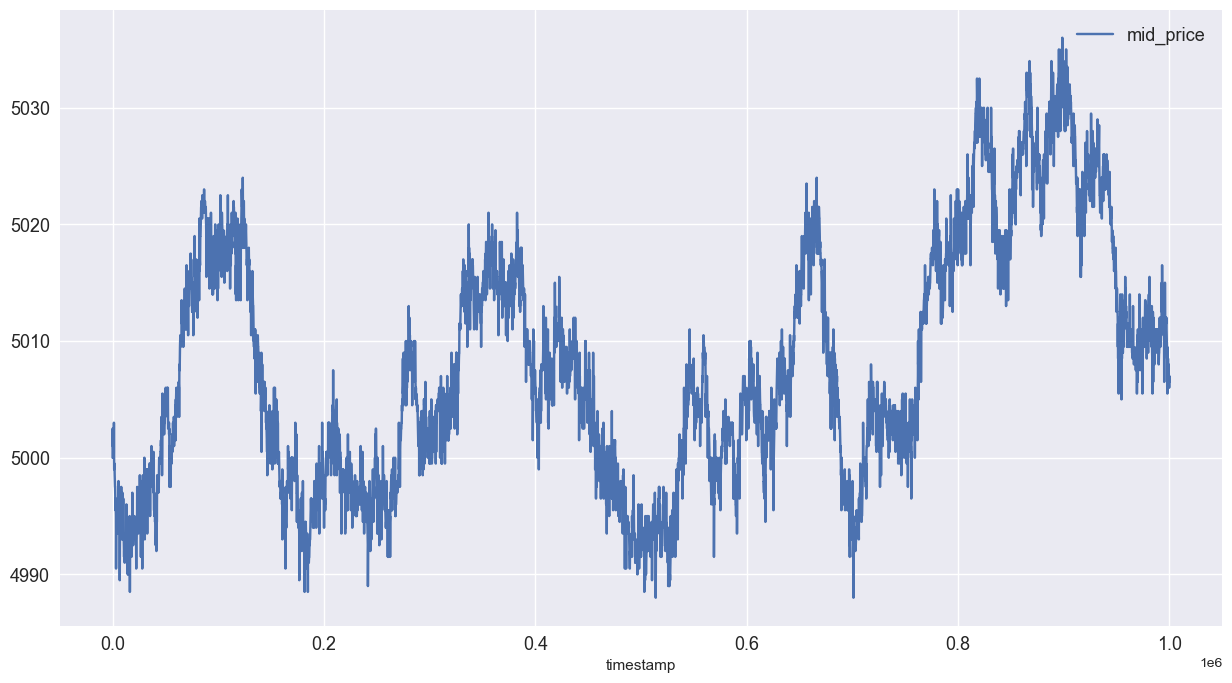

In [5]:
t.mid_price.plot(figsize = (15, 8), fontsize = 13)
plt.legend(fontsize = 13)
plt.show()

In [6]:
x_model = np.arange(0, 1000000, 100)

In [7]:
x_model.shape

(10000,)

In [8]:
ones = np.ones((len(x_model)))
ones.shape

(10000,)

In [9]:
X = np.vstack([ones, x_model]).T
X.shape

(10000, 2)

In [10]:
Y = t.mid_price.values.reshape((len(t.mid_price), 1))

In [11]:
X.shape, Y.shape

((10000, 2), (10000, 1))

In [12]:
beta = np.linalg.inv(X.T.dot(X)).dot(X.T.dot(Y))
beta

array([[4.99963059e+03],
       [1.66374884e-05]])

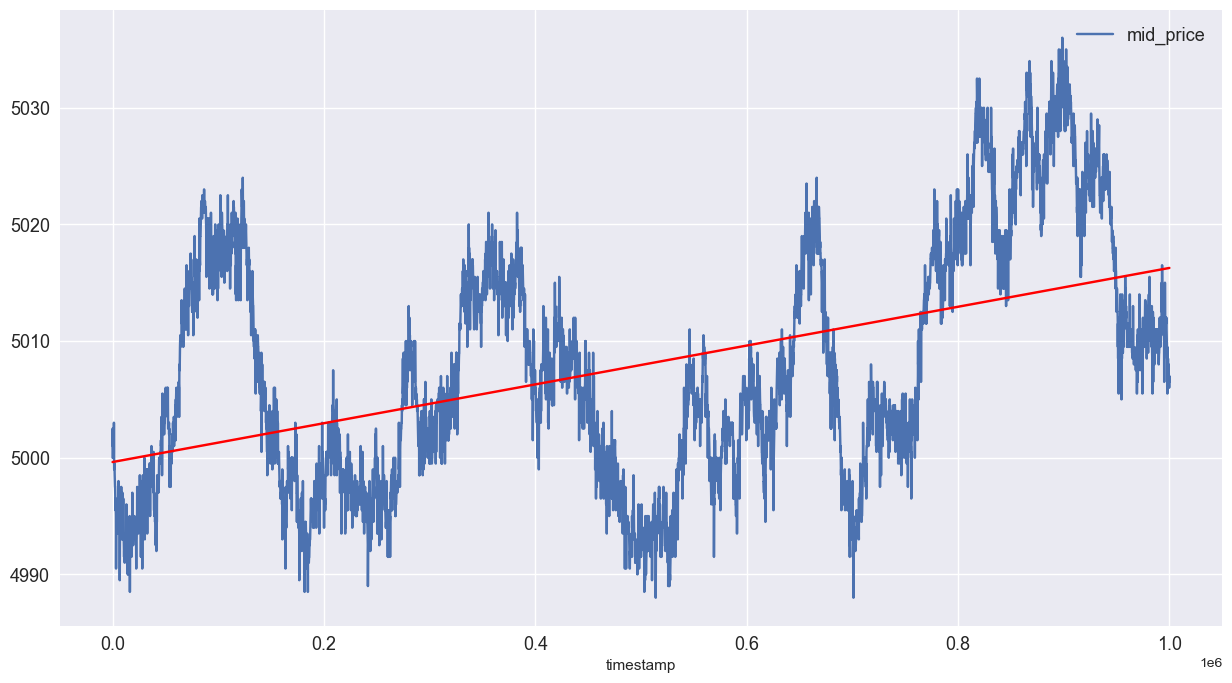

In [13]:
t.mid_price.plot(figsize = (15, 8), fontsize = 13)
x_model = np.arange(0, 1000000, 100)
y_model = t.index * beta[1] + beta[0]
plt.plot(x_model, y_model, 'r-')
plt.legend(fontsize = 13)
plt.show()

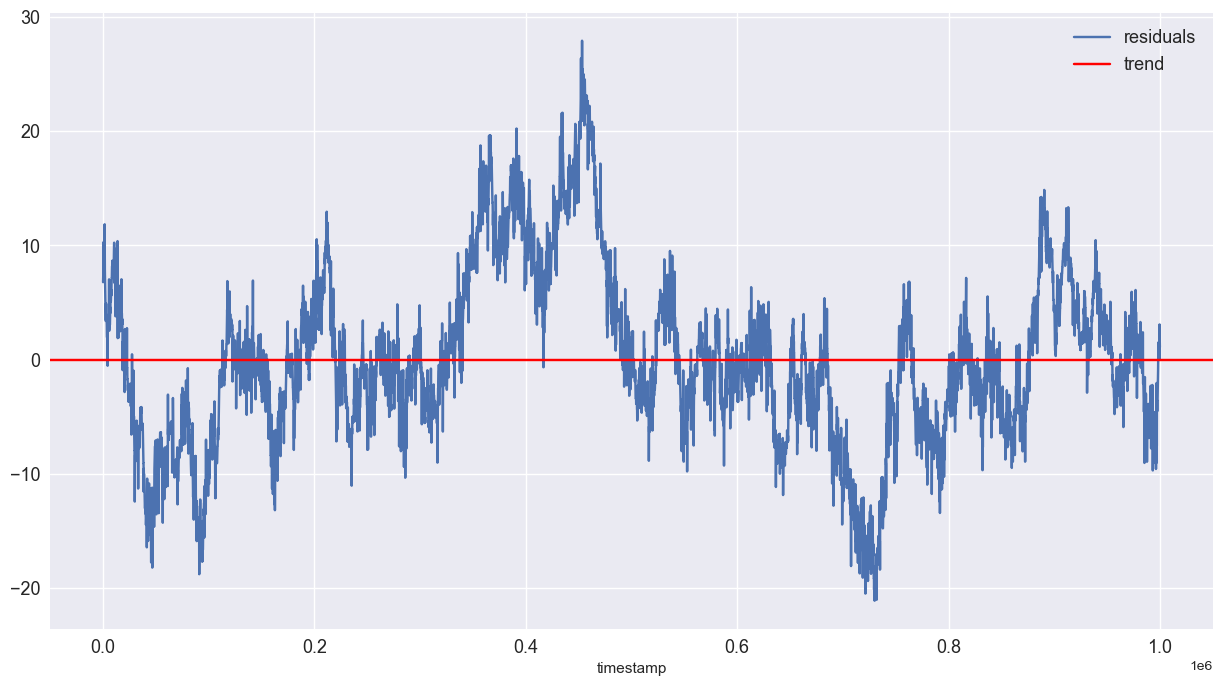

In [42]:
y_fitted = t.index * beta[1] + beta[0]
residuals = t.mid_price - y_fitted
residuals.plot(figsize=(15, 8), fontsize=13, label="residuals")
plt.axhline(0, color='r', linestyle='-', label = "trend")
plt.legend(fontsize = 13)
plt.show()